# 04. Biological Recovery Model

이번 단계에서는 인터페이스 손상 이후
유효 신호 결합 계수 $h$가 시간에 따라 회복한다고
가정하는 최소 모델을 만든다.

이전 단계에서는 손상 이후의 결합 계수를
고정된 값으로 두었다.

$$
h = 1-d
$$

이번에는 이를 시간의 함수

$$
h(t)
$$

로 확장한다.

여기서 $t$는 실제 초, 일, 년을 의미하지 않는
정규화된 느린 시간 변수이다.

본 단계의 회복 모델은 실제 생물학적 회복 속도를
예측하기 위한 모델이 아니다.

손상된 신호 결합이 일정한 지연 이후 점진적으로
회복한다는 가정을 수학적으로 표현하기 위한
최소 가설 모델이다.

In [1]:
damage = 0.5

h_ititial = 1.0 - damage

print(h_ititial)

0.5


## Recovery model

손상 시점을 $t_d$, 손상 크기를 $d$,
회복 지연을 $L$, 회복률을 $k$라고 정의한다.

결합 계수는 다음과 같이 정의한다.

$$
h(t)=
\begin{cases}
1,
& t<t_d
\\
1-d,
& t_d\le t<t_d+L
\\
(1-d)
+
[h_{\max}-(1-d)]
\left(
1-e^{-k(t-t_d-L)}
\right),
& t\ge t_d+L
\end{cases}
$$

$k$가 클수록 빠르게 회복하며,
$h_{\max}$는 최종적으로 도달 가능한 결합 수준을 의미한다.

이 파라미터들은 현재 단계에서는 정규화된 모델의
가정값이며 실제 생물학적 측정값이 아니다.

In [59]:
import numpy as np
import matplotlib.pyplot as plt

In [60]:
#함수구현
def coupling(
    t,
    damage = 0.5,
    repair_rate = 0.3,
    repair_delay = 2.0,
    damage_time = 3.0,
    h_max = 1.0
):

    t = np.asarray(t, dtype=float)

    assert 0 <= damage < 1
    assert repair_rate >= 0
    assert repair_delay >= 0

    h_initial = 1.0 - damage

    assert h_initial <= h_max <= 1.0

    elapsed = np.maximum(
        t - damage_time - repair_delay,
        0.0
    )

    repaired = (
        h_initial
        + (h_max - h_initial)
        * (1 - np.exp(-repair_rate * elapsed))
    )

    h = np.where(
        t < damage_time,
        1.0,
        repaired
    )

    return h    

In [61]:
#시뮬레이션 시간 설정
dt = 0.05

t = np.arange(
    0,
    30 + dt/2,
    dt
)

In [62]:
#파라미터 정의
damage_time = 3.0
damage = 0.5

repair_delay = 2.0
repair_rate = 0.3
repair_rates = [0.1, 0.3, 1.0]

h_max = 1.0

In [63]:
h = coupling(
    t,
    damage=damage,
    repair_rate=repair_rate,
    repair_delay=repair_delay,
    damage_time=damage_time,
    h_max=h_max
)

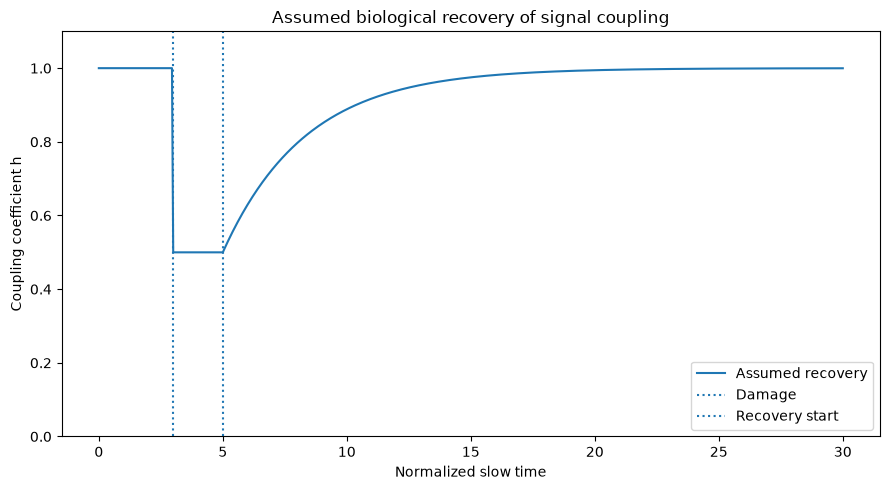

In [64]:
plt.figure(figsize=(9, 5))

plt.plot(
    t,
    h,
    label="Assumed recovery"
)

plt.axvline(
    damage_time,
    linestyle=":",
    label="Damage"
)

plt.axvline(
    damage_time + repair_delay,
    linestyle=":",
    label="Recovery start"
)

plt.xlabel("Normalized slow time")
plt.ylabel("Coupling coefficient h")
plt.title("Assumed biological recovery of signal coupling")

plt.ylim(0, 1.1)

plt.legend()

plt.tight_layout()
plt.show()

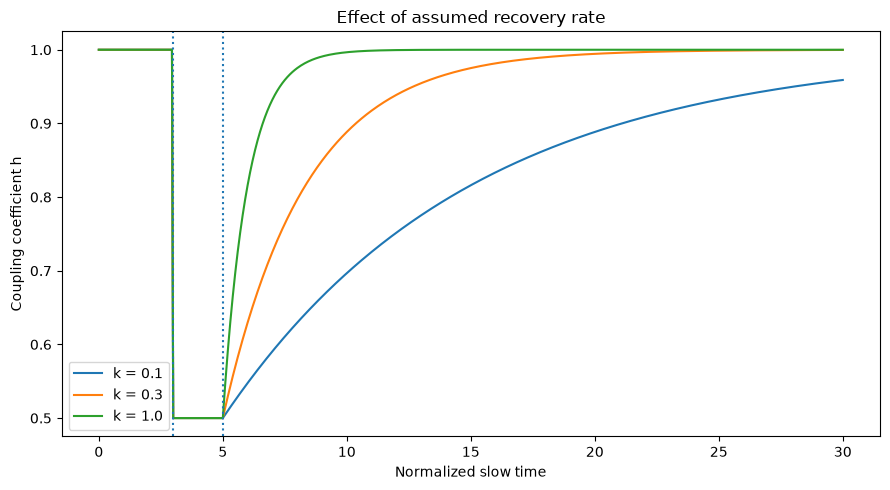

In [65]:
#rate_rates 그래프 비교

plt.figure(figsize=(9, 5))

for rate in repair_rates:

    h_test = coupling(
        t,
        damage=damage,
        repair_rate=rate,
        repair_delay=repair_delay,
        damage_time=damage_time,
        h_max=h_max
    )

    plt.plot(
        t,
        h_test,
        label=f"k = {rate}"
    )

plt.axvline(
    damage_time,
    linestyle=":"
)

plt.axvline(
    damage_time + repair_delay,
    linestyle=":"
)

plt.xlabel("Normalized slow time")
plt.ylabel("Coupling coefficient h")

plt.title("Effect of assumed recovery rate")

plt.legend()

plt.tight_layout()
plt.show()

In [66]:
#회복없는경우(비교대상)

h_no_repair = np.where(
    t < damage_time,
    1.0,
    1.0 - damage
)

h_repair = coupling(
    t,
    damage=damage,
    repair_rate=repair_rate,
    repair_delay=repair_delay,
    damage_time=damage_time,
    h_max=h_max
)

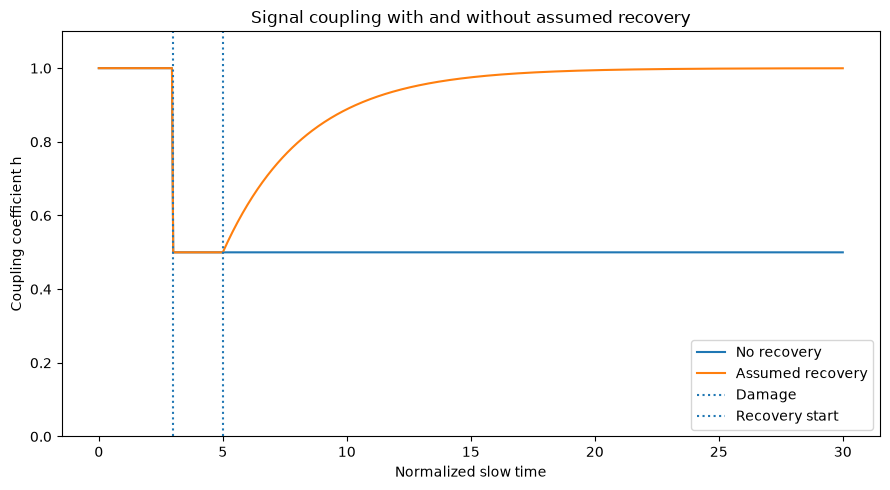

In [68]:
plt.figure(figsize=(9, 5))

plt.plot(
    t,
    h_no_repair,
    label="No recovery"
)

plt.plot(
    t,
    h_repair,
    label="Assumed recovery"
)

plt.axvline(
    damage_time,
    linestyle=":",
    label="Damage"
)

plt.axvline(
    damage_time + repair_delay,
    linestyle=":",
    label="Recovery start"
)

plt.xlabel("Normalized slow time")
plt.ylabel("Coupling coefficient h")

plt.title(
    "Signal coupling with and without assumed recovery"
)

plt.ylim(0, 1.1)

plt.legend()

plt.tight_layout()
plt.show()

In [69]:
#불완전 회복 hmax = 1 이 아닌 hmax = 0.8로

h_partial = coupling(
    t,
    damage = 0.5,
    repair_rate = 0.3,
    repair_delay=2.0,
    damage_time=3.0,
    h_max=0.8
)

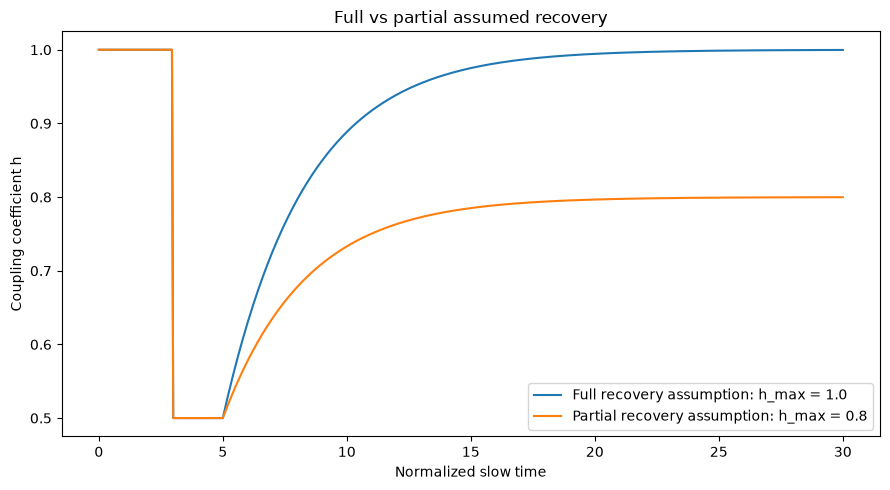

In [70]:
plt.figure(figsize=(9, 5))

plt.plot(
    t,
    h_repair,
    label="Full recovery assumption: h_max = 1.0"
)

plt.plot(
    t,
    h_partial,
    label="Partial recovery assumption: h_max = 0.8"
)

plt.xlabel("Normalized slow time")
plt.ylabel("Coupling coefficient h")

plt.title("Full vs partial assumed recovery")

plt.legend()

plt.tight_layout()
plt.show()

In [71]:
#자동 검증

h_test = coupling(
    t,
    damage=damage,
    repair_rate=repair_rate,
    repair_delay=repair_delay,
    damage_time=damage_time,
    h_max=h_max
)

#손상 전에는 h=1
assert np.allclose(
    h_test[t < damage_time],
    1.0
)

#손상 이후 최소값보다 작아지면 안 됨
assert np.all(
    h_test[t >= damage_time]
    >= 1.0 - damage
)

#정상 기준을 초과하면 안 됨
assert np.all(
    h_test <= 1.0
)

#recovery rate = 0이면 회복없음
h_zero_rate = coupling(
    t,
    damage=damage,
    repair_rate=0.0,
    repair_delay=repair_delay,
    damage_time=damage_time,
    h_max=h_max
)

expected_no_recovery = np.where(
    t < damage_time,
    1.0,
    1.0 - damage
)

assert np.allclose(
    h_zero_rate,
    expected_no_recovery
)

print("Biological recovery hypothesis model validation passed.")



Biological recovery hypothesis model validation passed.
